# Advacned Deep Learning - Multimodal Retrieval with CLIP on Flickr8k, Training

Author: Nicolas Vogel

Submission date: 15.12.2025

course: Advanced Deep Learning (AS 2025)

## Sections
0. Introduction
1. Pre-Setting, Imports and Data Loading
2. Function to test model
3. Model Evaluation
  3.1 CLIP off the shelf
  3.2 Finetuned Model
4. Visualization of Retrieval Results

# 0. Introduction
In this notebook, we implement a multimodal retrieval system using the CLIP model on the Flickr8k dataset. We will first evaluate the off-the-shelf CLIP model and then test a finetuned version of the model. The evaluation will be based on standard retrieval metrics such as Recall@K.

# 1.0 Pre-Setting, Imports and Data Loading
In this section, we set up the environment, import necessary libraries, and load the Flickr8k dataset.

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from pathlib import Path
from transformers import CLIPProcessor, CLIPModel
import torch
import importlib


import my_dataset
importlib.reload(my_dataset)
from my_dataset import Flickr8kDataset
import utils
importlib.reload(utils)
from utils import *
import matplotlib.pyplot as plt




In [52]:
# ============= set project root
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # fallback for Jupyter notebooks
    PROJECT_ROOT = find_project_root()

# ============= PROJECT_ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data"
IMG_DIR = DATA_DIR / "Images"
CAPTIONS_FILE = DATA_DIR / "flickr8k_captions.csv"
RUNS_DIR = PROJECT_ROOT / "runs"

test_model = True

batch_size = 64
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    num_workers = 4
else:
    DEVICE = torch.device("cpu")
    num_workers = 0

In [53]:
# =========== load csv file with captions
captions = pd.read_csv(CAPTIONS_FILE, sep=";", engine="python")

# get unique images for proper splitting
images = captions["filename"].unique()

# split into train, val, test
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(test_imgs, test_size=0.5, random_state=42)

# filter captions dataframe based on image splits
train_df = captions[captions["filename"].isin(train_imgs)]
val_df   = captions[captions["filename"].isin(val_imgs)]
test_df  = captions[captions["filename"].isin(test_imgs)]


# create datasets
train_dataset = Flickr8kDataset(str(IMG_DIR), train_df)
val_dataset   = Flickr8kDataset(str(IMG_DIR), val_df)
test_dataset  = Flickr8kDataset(str(IMG_DIR), test_df)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# 2.0 Function to test model
Function to test model with retrieval metrics on test set.



In [54]:


def evaluate_clip_image2text_recall(
        model_path,
        model_name,
        test_loader,
        device="cpu"
    ):
    """
    Calculates Recall@K (Image -> Text) for a CLIP model.

    Returns:
        dict: {"recall@1": ..., "recall@5": ..., "recall@10": ...}
    """

    # ==== Load model ====
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)

    if model_path is not None:
        state = torch.load(model_path, map_location=torch.device(device))
        model.load_state_dict(state)

    model.to(device)
    model.eval()


    # ==== collect Embeddings ====
    all_image_embs = []
    all_text_embs = []
    num_samples = 0

    with torch.no_grad():
        for batch_images, batch_texts in test_loader:
            inputs = processor(
                images=batch_images,
                text=batch_texts,
                padding=True,
                return_tensors="pt"
            ).to(device)

            img = model.get_image_features(pixel_values=inputs["pixel_values"])
            txt = model.get_text_features(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )

            img = img / img.norm(dim=-1, keepdim=True)
            txt = txt / txt.norm(dim=-1, keepdim=True)

            all_image_embs.append(img)
            all_text_embs.append(txt)

            num_samples += len(batch_texts)

    all_image_embs = torch.cat(all_image_embs, dim=0)
    all_text_embs = torch.cat(all_text_embs, dim=0)

    # ==== Similarity-Matrix ====
    sims = all_image_embs @ all_text_embs.T


    # ===== Compute Recall@K =====
    recall_at_1_img2text = 0
    recall_at_5_img2text = 0
    recall_at_10_img2text = 0

    # Image -> Text
    for i in range(num_samples):
        topk = sims[:, i].topk(10).indices
        if i in topk[:1]:
            recall_at_1_img2text += 1
        if i in topk[:5]:
            recall_at_5_img2text += 1
        if i in topk[:10]:
            recall_at_10_img2text += 1

    # Normalize
    recall_at_1_img2text /= num_samples
    recall_at_5_img2text /= num_samples
    recall_at_10_img2text /= num_samples

    recalls = {
        "recall@1": recall_at_1_img2text,
        "recall@5": recall_at_5_img2text,
        "recall@10": recall_at_10_img2text
    }

    return recalls


# 2.1 Model Evaluation
In this section, we evaluate both the off-the-shelf CLIP model and the finetuned model on the test set using retrieval metrics.

In [57]:
of_the_shelf = evaluate_clip_image2text_recall(
    model_path=None,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')



It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


In [58]:
path_overfit = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251124_hpc_overfit_run/20251124_clip_cuda_sub-size-full_bs32_ep500_lr1e-05_ft_training_no-earlystop/20251124_clip_cuda_sub-size-full_bs32_ep500_lr1e-05_ft_training_no-earlystop_model.pth"

overfit = evaluate_clip_image2text_recall(
    model_path=path_overfit,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')

In [59]:
path_bs_temp = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251125_hpc_bs64_temp0.12/20251125_clip_cuda_sub-size-full_bs64_ep200_lr1e-05_x_bs_temp0.12/20251125_clip_cuda_sub-size-full_bs64_ep200_lr1e-05_x_bs_temp0.12_model.pth"

bs_temp = evaluate_clip_image2text_recall(
    model_path=path_bs_temp,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')

In [60]:
path_prog_unfreez = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251202_hpc_prog-unfreez-V2/20251202_clip_cuda_sub-size-full_bs64_ep200_lr1e-05_prog_unfreeze_V2_model.pth"

prog_unfreez = evaluate_clip_image2text_recall(
    model_path=path_prog_unfreez,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')

In [61]:
path_lr_schedule = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251207_hpc_LR-schedule/20251207_clip_cuda_sub-size-full_bs64_ep200_lr1e-05_LR-schedule_model.pth"

lr_schedule = evaluate_clip_image2text_recall(
    model_path=path_lr_schedule,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')

In [63]:
path_grad_clip = "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval_Misc/251208_hpc_LR-schedule_2/20251208_clip_cuda_sub-size-full_bs64_ep200_lr1e-05_LR-schedule_model.pth"

grad_clip = evaluate_clip_image2text_recall(
    model_path=path_grad_clip,
    model_name="openai/clip-vit-base-patch32",
    test_loader=test_loader,
    device='cpu')

In [13]:
# of_the_shelf = {'recall@1': 0.0002469135802469136, 'recall@5': 0.0014814814814814814, 'recall@10': 0.0027160493827160493}
# overfit =  {'recall@1': 0.005925925925925926, 'recall@5': 0.03259259259259259, 'recall@10': 0.05703703703703704}
# bs_temp = {'recall@1': 0.009135802469135803, 'recall@5': 0.04814814814814815, 'recall@10': 0.07802469135802469}
# prog_unfreez = {'recall@1': 0.006172839506172839, 'recall@5': 0.02666666666666667, 'recall@10': 0.04617283950617284}
# lr_schedule = {'recall@1': 0.006172839506172839, 'recall@5': 0.02666666666666667, 'recall@10': 0.04617283950617284}

In [64]:
print("Off-the-shelf CLIP:", of_the_shelf)
print("Finetuned CLIP (overfit):", overfit)
print("Finetuned CLIP (bs+temp):", bs_temp)
print("Finetuned CLIP (prog unfreez):", prog_unfreez)
print("Finetuned CLIP (LR schedule):", lr_schedule)
print("Finetuned CLIP (Grad Clip):", grad_clip)


Off-the-shelf CLIP: {'recall@1': 0.0002469135802469136, 'recall@5': 0.0014814814814814814, 'recall@10': 0.0027160493827160493}
Finetuned CLIP (overfit): {'recall@1': 0.005925925925925926, 'recall@5': 0.03259259259259259, 'recall@10': 0.05703703703703704}
Finetuned CLIP (bs+temp): {'recall@1': 0.009135802469135803, 'recall@5': 0.04814814814814815, 'recall@10': 0.07802469135802469}
Finetuned CLIP (prog unfreez): {'recall@1': 0.0049382716049382715, 'recall@5': 0.021728395061728394, 'recall@10': 0.042222222222222223}
Finetuned CLIP (LR schedule): {'recall@1': 0.006172839506172839, 'recall@5': 0.02666666666666667, 'recall@10': 0.04617283950617284}
Finetuned CLIP (Grad Clip): {'recall@1': 0.007654320987654321, 'recall@5': 0.03382716049382716, 'recall@10': 0.05753086419753087}


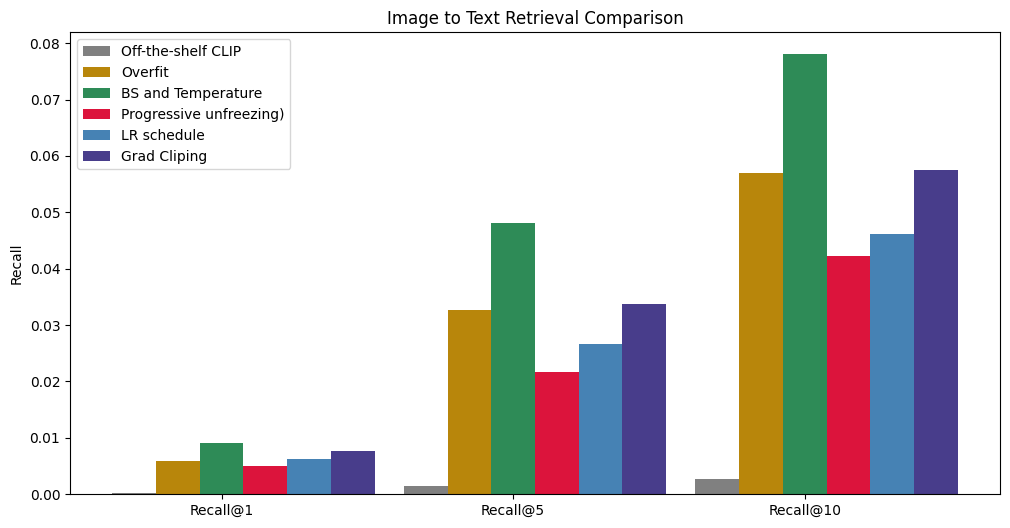

In [67]:
# plot results
labels = ['Recall@1', 'Recall@5', 'Recall@10']
of_the_shelf_vals = [of_the_shelf['recall@1'], of_the_shelf['recall@5'], of_the_shelf['recall@10']]
overfit_vals = [overfit['recall@1'], overfit['recall@5'], overfit['recall@10']]
bs_temp_vals = [bs_temp['recall@1'], bs_temp['recall@5'], bs_temp['recall@10']]
prog_unfreez_vals = [prog_unfreez['recall@1'], prog_unfreez['recall@5'], prog_unfreez['recall@10']]
lr_schedule_vals = [lr_schedule['recall@1'], lr_schedule['recall@5'], lr_schedule['recall@10']]
grad_clip_vals = [grad_clip['recall@1'], grad_clip['recall@5'], grad_clip['recall@10']]
x = range(len(labels))
plt.figure(figsize=(12, 6))
plt.bar([p - 0.3 for p in x], of_the_shelf_vals, width=0.15, label='Off-the-shelf CLIP', color = 'gray')
plt.bar([p - 0.15 for p in x], overfit_vals, width=0.15, label='Overfit', color = 'darkgoldenrod')
plt.bar([p for p in x], bs_temp_vals, width=0.15, label='BS and Temperature', color = 'seagreen')
plt.bar([p + 0.15 for p in x], prog_unfreez_vals, width=0.15, label='Progressive unfreezing)', color = 'crimson')
plt.bar([p + 0.3 for p in x], lr_schedule_vals, width=0.15, label='LR schedule', color = 'steelblue')
plt.bar([p + 0.45 for p in x], grad_clip_vals, width=0.15, label='Grad Cliping', color = 'darkslateblue')
plt.xticks(x, labels)
plt.ylabel('Recall')
plt.title('Image to Text Retrieval Comparison')
# plt.ylim(0, 1)
plt.legend()
# plt.tight_layout()
plt.show()

asdf



asdf





asdf






asdf








asdf

# Test finetuned model
Here the finetuned model is tested on the test set and retrieval metrics are computed.

# Visualize some retrieval results
In this section, we visualize some retrieval results by selecting a random image from the test set and displaying its top 5 retrieved captions.

3909


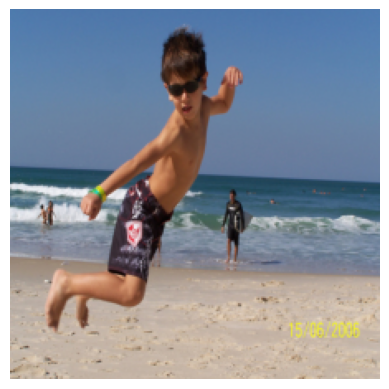

Top 5 retrieved captions:
- A boy with swimming trunks and goggles jumping on the sand by the beach
- a man playing with two black dogs on the beach
- A man in shorts with two black dogs holds a ball throwing toy at the beach .
- Man at the beach with two dogs .
- A man in a brown shirt and dark shorts plays on the beach with his two black dogs .

Real captions:
- A boy jumping in the air on the beach .
- A boy with swimming trunks and goggles jumping on the sand by the beach
- A kid with sunglasses in jumping on the beach .
- A young boy jumping in the air at the beach .
- Boy in swim trunks jumping on beach


In [11]:
# example with test data: random image and its top 5 retrieved captions
if test_model:
    import random
    random_idx = random.randint(0, len(test_dataset)-1)
    print(random_idx)
    random_image, _ = test_dataset[random_idx]
    inputs = processor(images=random_image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        image_emb = model.get_image_features(pixel_values=inputs["pixel_values"])
        image_emb = image_emb / image_emb.norm(dim=-1, keepdim=True)
    sims = image_emb @ all_text_embs.T  # [1, num_texts]
    topk = sims[0].topk(5).indices
    topk = topk.cpu().numpy()
    plt.imshow(random_image.permute(1, 2, 0))
    plt.axis("off")
    plt.show()
    print("Top 5 retrieved captions:")
    for idx in topk:
        print(f"- {test_dataset.captions.iloc[idx]['caption']}")

    # real caption of the image
    real_captions = test_dataset.captions[test_dataset.captions['filename'] == test_dataset.captions.iloc[random_idx]['filename']]['caption'].tolist()
    print("\nReal captions:")
    for caption in real_captions:
        print(f"- {caption}")

# Zeroshot Retrieval with CLIP

In [46]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# Modell und Processor laden
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# --- Deine Daten ---
# Beispielbilder laden
image_paths = ["/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/DSC01466.JPG", "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/DSC00520.JPG", "/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/IMG_5575.jpeg"]

# Beispiel-Captions (Klassen oder Beschreibungen)
captions = ["eine Katze", "ein Hund", "ein Auto", "ein Baum", "ein Haus",  "ein Strand", "ein Berg", "eine Stadtansicht", "ein Flugzeug", "ein Fahrrad", "ein Boot", "ein Vogel", "ein Fisch", "ein Pferd", "ein Elefant", "ein Computer", "ein Telefon", "eine Blume", "ein Buch", "ein Stuhl", "ein Tisch", "ein Mann mit Helm", "eine Frau mit Hut", "ein Mann beim Bogenschiessen", "ein Kind beim Spielen", "eine Gruppe von Menschen", "ein Sonnenuntergang", "ein Regenbogen", "ein Wasserfall", "ein Fluss", "ein See", "Menschen beim Yoga", "Personen beim spielen", "eine Gruppe von Freunden", "ein Musiker auf der Bühne", "ein Koch in der Küche"]
images = [Image.open(p) for p in image_paths]

# --- Embeddings vorbereiten ---
with torch.no_grad():
    img_inputs = processor(images=images, return_tensors="pt").to(device)
    img_embs = model.get_image_features(**img_inputs)
    img_embs = img_embs / img_embs.norm(p=2, dim=-1, keepdim=True)

    txt_inputs = processor(text=captions, return_tensors="pt", padding=True).to(device)
    txt_embs = model.get_text_features(**txt_inputs)
    txt_embs = txt_embs / txt_embs.norm(p=2, dim=-1, keepdim=True)

# --- Bild → passende Caption für jedes Bild ---
for i, path in enumerate(image_paths):
    sim = (img_embs[i] @ txt_embs.T)          # Ähnlichkeit zu allen Captions
    best_idx = sim.argmax().item()           # Beste Caption finden
    print(f"{path} → {captions[best_idx]}")


/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/DSC01466.JPG → ein Kind beim Spielen
/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/DSC00520.JPG → Menschen beim Yoga
/Users/nicolasvogel/Dokumente/16_ZHAW_MSc/V5_9_Adcanced_Deep_Learning/ADL_multimodal-retrieval/notebooks/IMG_5575.jpeg → ein Mann mit Helm
